In [ ]:
# ── Cell 1: Configure Kaggle API (new token format) ───────────────────────────
import os
import json

KAGGLE_USERNAME = "beyzaakgn"        # ← your Kaggle username
KAGGLE_KEY = "KGAT_077b31b103718c0463a9a6ce2a104a31"       # ← your NEW token after regenerating

os.makedirs("/root/.config/kaggle", exist_ok=True)
with open("/root/.config/kaggle/kaggle.json", "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

os.chmod("/root/.config/kaggle/kaggle.json", 0o600)
print("Kaggle API configured!")

✅ Kaggle API configured!


In [ ]:
# ── Cell 2: Install Kaggle & download dataset ─────────────────────────────────
!pip install kaggle -q

!kaggle datasets download -d blastchar/telco-customer-churn --unzip -p /content/data/

import os
print("Files downloaded:")
for f in os.listdir("/content/data/"):
    print(f"   └── {f}")

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 91.6MB/s]

📁 Files downloaded:
   └── WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [ ]:
df = pd.read_csv("/content/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
print(f"Dataset loaded!")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n{'─'*50}")
print(df.head())

✅ Dataset loaded!
   Shape: 7043 rows × 21 columns

──────────────────────────────────────────────────
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic 

In [ ]:
print("COLUMN TYPES & NON-NULL COUNTS")
print(df.info())

📋 COLUMN TYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperless

In [ ]:
print("\n BASIC STATISTICS")
display(df.describe())


📊 BASIC STATISTICS


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
print("\n MISSING VALUES")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")


 MISSING VALUES
No missing values found!


In [ ]:
print("\n TARGET DISTRIBUTION (Churn)")
print(df["Churn"].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")


 TARGET DISTRIBUTION (Churn)
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%


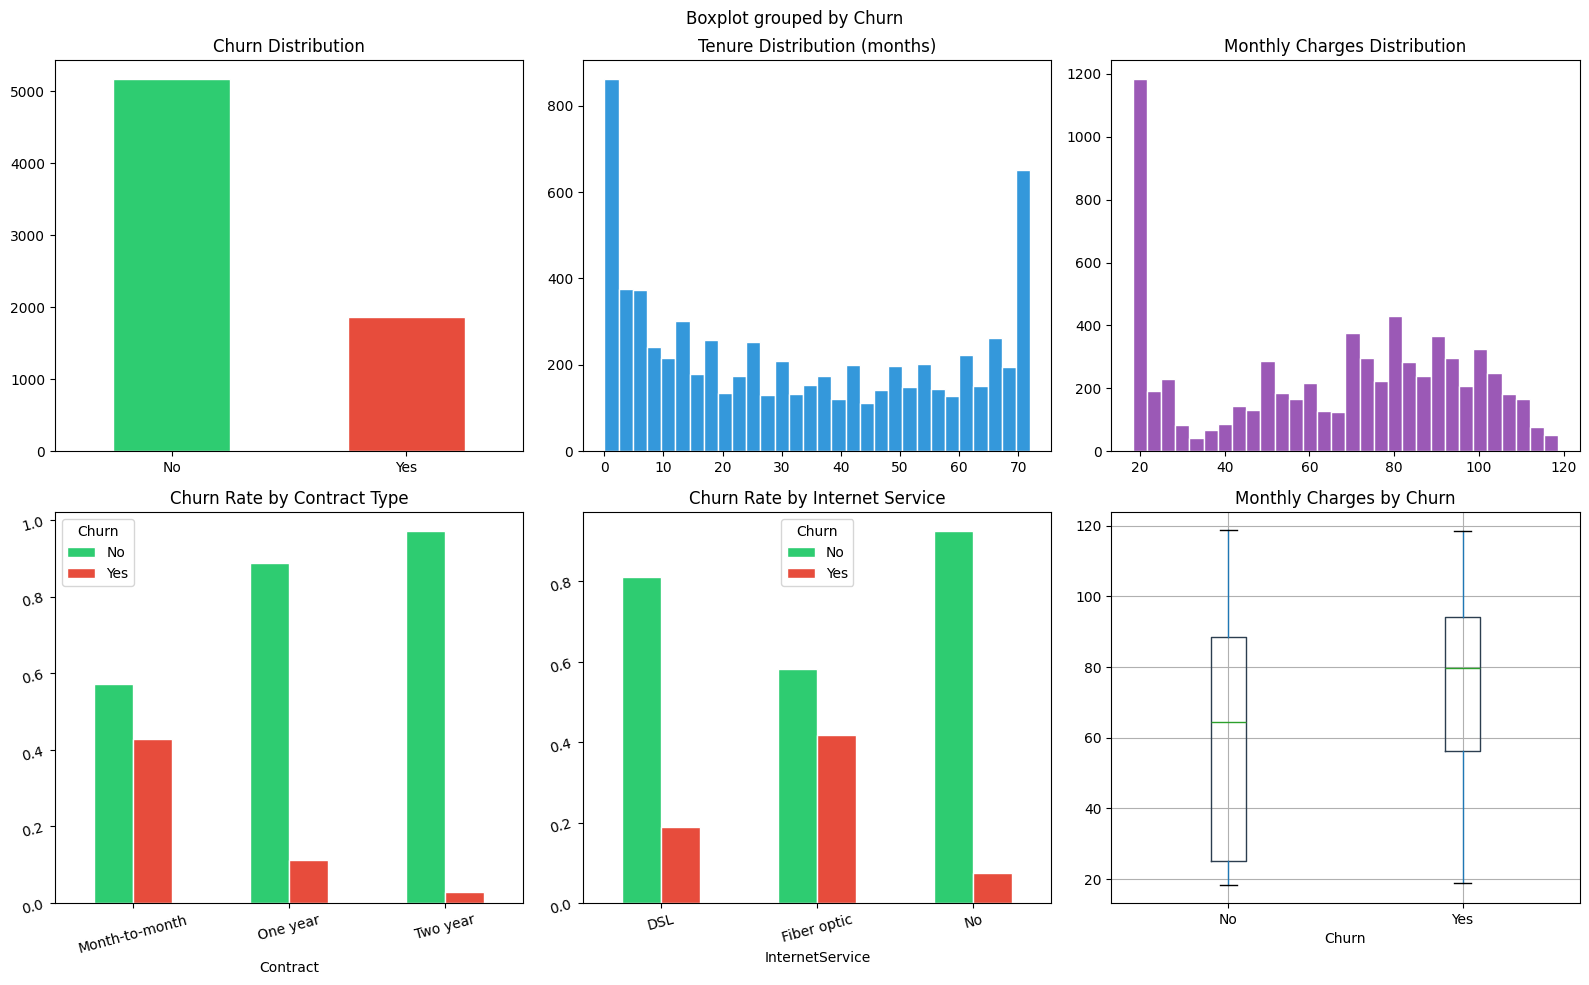

✅ EDA chart saved!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Telco Churn - EDA Overview", fontsize=16, fontweight="bold")

# 1. Churn distribution
df["Churn"].value_counts().plot(kind="bar", ax=axes[0,0], color=["#2ecc71","#e74c3c"], edgecolor="white")
axes[0,0].set_title("Churn Distribution")
axes[0,0].set_xlabel("")
axes[0,0].tick_params(rotation=0)

# 2. Tenure distribution
axes[0,1].hist(df["tenure"], bins=30, color="#3498db", edgecolor="white")
axes[0,1].set_title("Tenure Distribution (months)")

# 3. Monthly charges
axes[0,2].hist(df["MonthlyCharges"], bins=30, color="#9b59b6", edgecolor="white")
axes[0,2].set_title("Monthly Charges Distribution")

# 4. Contract type vs Churn
pd.crosstab(df["Contract"], df["Churn"], normalize="index").plot(
    kind="bar", ax=axes[1,0], color=["#2ecc71","#e74c3c"], edgecolor="white")
axes[1,0].set_title("Churn Rate by Contract Type")
axes[1,0].tick_params(rotation=15)
axes[1,0].legend(title="Churn")

# 5. Internet service vs Churn
pd.crosstab(df["InternetService"], df["Churn"], normalize="index").plot(
    kind="bar", ax=axes[1,1], color=["#2ecc71","#e74c3c"], edgecolor="white")
axes[1,1].set_title("Churn Rate by Internet Service")
axes[1,1].tick_params(rotation=15)

# 6. Monthly charges vs Churn (boxplot)
df.boxplot(column="MonthlyCharges", by="Churn", ax=axes[1,2],
           boxprops=dict(color="#2c3e50"))
axes[1,2].set_title("Monthly Charges by Churn")

plt.tight_layout()
plt.savefig("/content/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA chart saved!")

In [ ]:
# Fix TotalCharges (object → numeric, spaces become NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
print(f"NaN in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")


NaN in TotalCharges after conversion: 11


In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])

In [ ]:
df["Churn"] = (df["Churn"] == "Yes").astype(int)

In [ ]:
df = df.drop(columns=["customerID"])

In [ ]:
print(f"Cleaning done! Shape: {df.shape}")
print(f"Churn value counts: {df['Churn'].value_counts().to_dict()}")

✅ Cleaning done! Shape: (7043, 20)
Churn value counts: {0: 5174, 1: 1869}


In [ ]:
df["TotalCharges"].dtype

dtype('float64')

In [ ]:
# 1. TENURE GROUPS
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 60, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-5yr", "5-6yr"],
    include_lowest=True
)

In [ ]:
# 2. CHARGES FEATURES
df["avg_monthly_spend"]     = df["TotalCharges"] / (df["tenure"] + 1)
df["charges_to_tenure"]     = df["MonthlyCharges"] / (df["tenure"] + 1)
df["high_value_customer"]   = (df["MonthlyCharges"] > df["MonthlyCharges"].median()).astype(int)

In [ ]:
# 3. SERVICE COUNT (how many add-ons the customer has)
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
df["service_count"] = df[service_cols].apply(lambda x: (x == "Yes").sum(), axis=1)


In [ ]:
# 4. PAYMENT BEHAVIOR
df["auto_payment"] = df["PaymentMethod"].isin(
    ["Bank transfer (automatic)", "Credit card (automatic)"]
).astype(int)

In [ ]:
# 5. RISK SCORE (rule-based, to be used as a feature)
df["risk_score"] = (
    (df["Contract"] == "Month-to-month").astype(int) * 3 +
    (df["tenure"] < 12).astype(int) * 2 +
    (df["InternetService"] == "Fiber optic").astype(int) * 2 +
    (df["auto_payment"] == 0).astype(int) * 1
)

print("Features engineered!")
print(f"\nNew columns added:")
new_cols = ["tenure_group","avg_monthly_spend","charges_to_tenure",
            "high_value_customer","service_count","auto_payment","risk_score"]
for col in new_cols:
    print(f"   └── {col}: {df[col].dtype} | sample: {df[col].iloc[0]}")

✅ Features engineered!

New columns added:
   └── tenure_group: category | sample: 0-1yr
   └── avg_monthly_spend: float64 | sample: 14.925
   └── charges_to_tenure: float64 | sample: 14.925
   └── high_value_customer: int64 | sample: 0
   └── service_count: int64 | sample: 1
   └── auto_payment: int64 | sample: 0
   └── risk_score: int64 | sample: 6


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Binary Yes/No columns → 0/1
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling",
               "MultipleLines", "OnlineSecurity", "OnlineBackup",
               "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0, "No phone service": 0,
                            "No internet service": 0})

# Multi-class categoricals → label encode
label_cols = ["gender", "InternetService", "Contract",
              "PaymentMethod", "tenure_group"]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("All categoricals encoded!")
print(f"\nFinal dataset shape: {df.shape}")
print(f"\nAll dtypes numeric: {all(df.dtypes != 'object')}")
display(df.head(3))

✅ All categoricals encoded!

Final dataset shape: (7043, 27)

All dtypes numeric: True


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,tenure_group,avg_monthly_spend,charges_to_tenure,high_value_customer,service_count,auto_payment,risk_score
0,0,0,1,0,1,0,0,0,0,1,...,29.85,29.85,0,0,14.925000,14.925000,0,1,0,6
1,1,0,0,0,34,1,0,0,1,0,...,56.95,1889.50,0,2,53.985714,1.627143,0,2,0,1
2,1,0,0,0,2,1,0,0,1,1,...,53.85,108.15,1,0,36.050000,17.950000,0,2,0,6


In [ ]:
# ── Cell 9: Train/Test Split ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data split done!")
print(f"   Train: {X_train.shape} | Churners: {y_train.sum()}")
print(f"   Test:  {X_test.shape}  | Churners: {y_test.sum()}")

✅ Data split done!
   Train: (5634, 26) | Churners: 1495
   Test:  (1409, 26)  | Churners: 374


In [ ]:
# ── Cell 10: Train XGBoost ────────────────────────────────────────────────────
!pip install xgboost -q
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # handle imbalance
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\n✅ XGBoost model trained!")

[0]	validation_0-logloss:0.67620
[50]	validation_0-logloss:0.48806
[100]	validation_0-logloss:0.47928


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:45:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[150]	validation_0-logloss:0.47862
[200]	validation_0-logloss:0.47761
[250]	validation_0-logloss:0.47685
[299]	validation_0-logloss:0.47811

✅ XGBoost model trained!


📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.82      1035
       Churn       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.75      0.76      1409

🎯 ROC-AUC Score: 0.8377


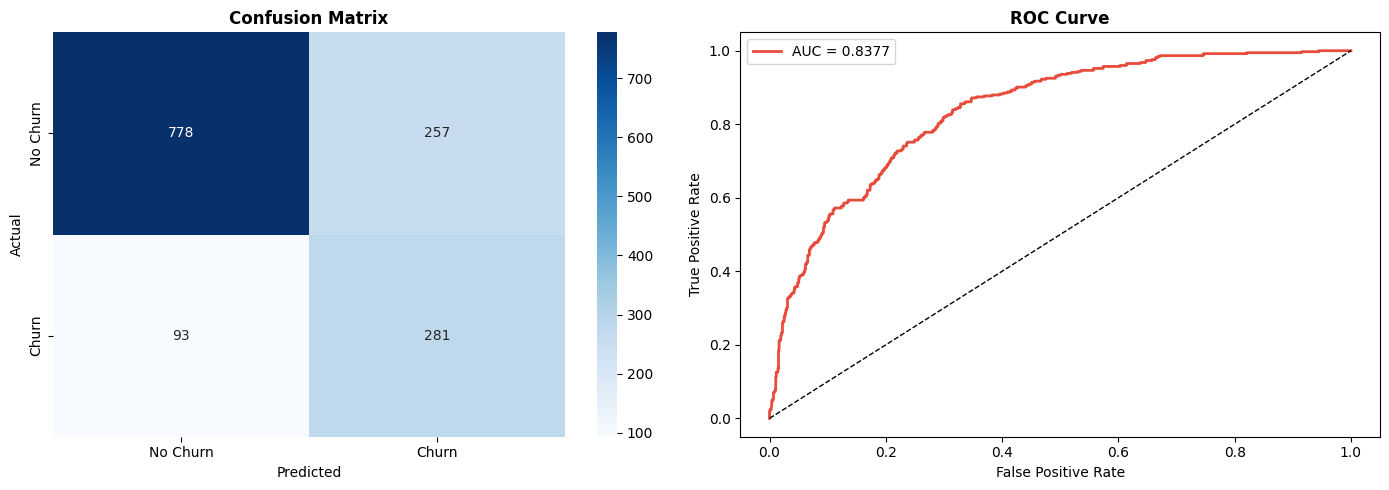

✅ Evaluation chart saved!


In [ ]:
# ── Cell 11: Model Evaluation ─────────────────────────────────────────────────
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"])
axes[0].set_title("Confusion Matrix", fontweight="bold")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# Plot 2 - ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#e74c3c", lw=2,
             label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.savefig("/content/model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Evaluation chart saved!")

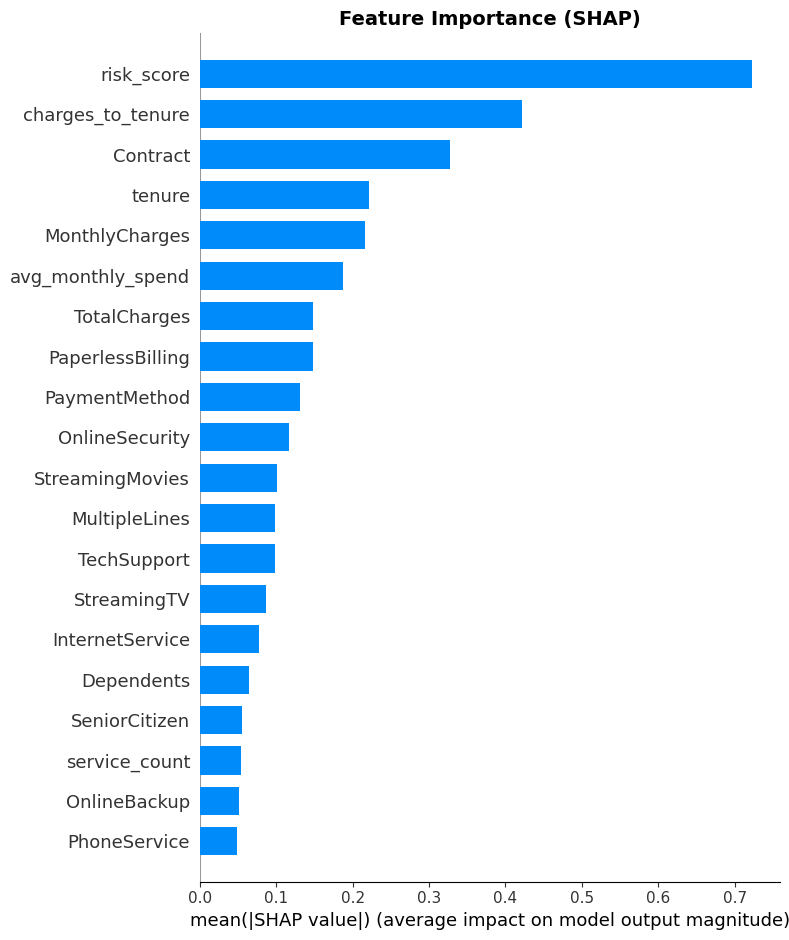

✅ SHAP importance plot saved!


In [ ]:
# ── Cell 12: SHAP Analysis ────────────────────────────────────────────────────
!pip install shap -q
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary Plot (most important features)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("/content/shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP importance plot saved!")

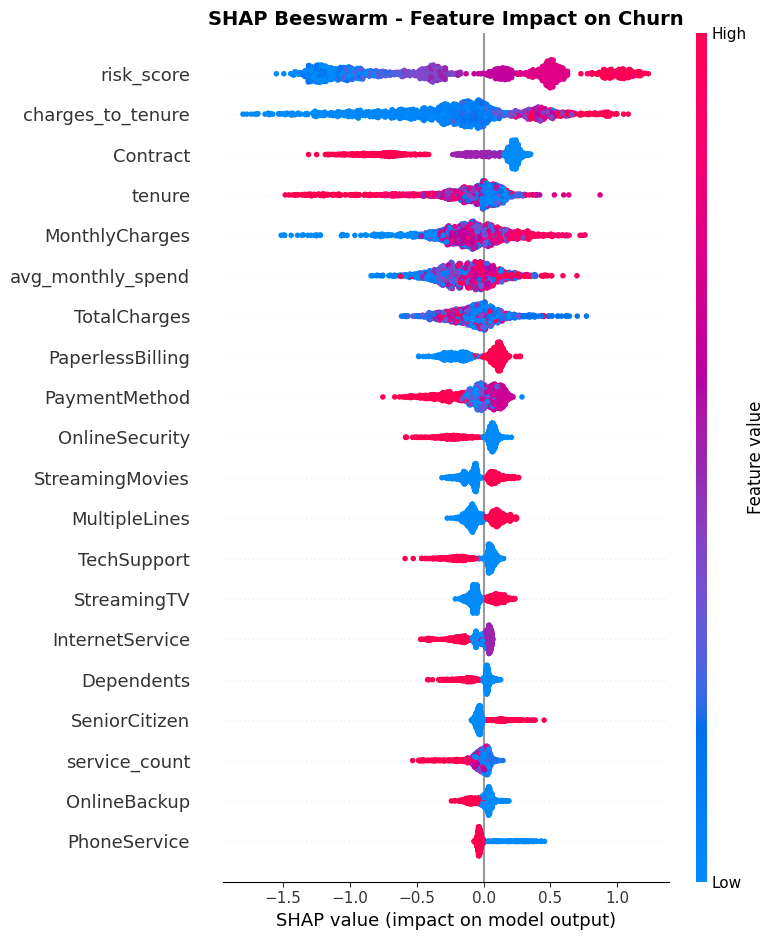

✅ SHAP beeswarm plot saved!


In [ ]:
# ── Cell 13: SHAP Beeswarm ────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm - Feature Impact on Churn", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("/content/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP beeswarm plot saved!")

🔍 Explaining prediction for customer at index: 1639
   Actual: Churn=1 | Predicted prob: 59.38%



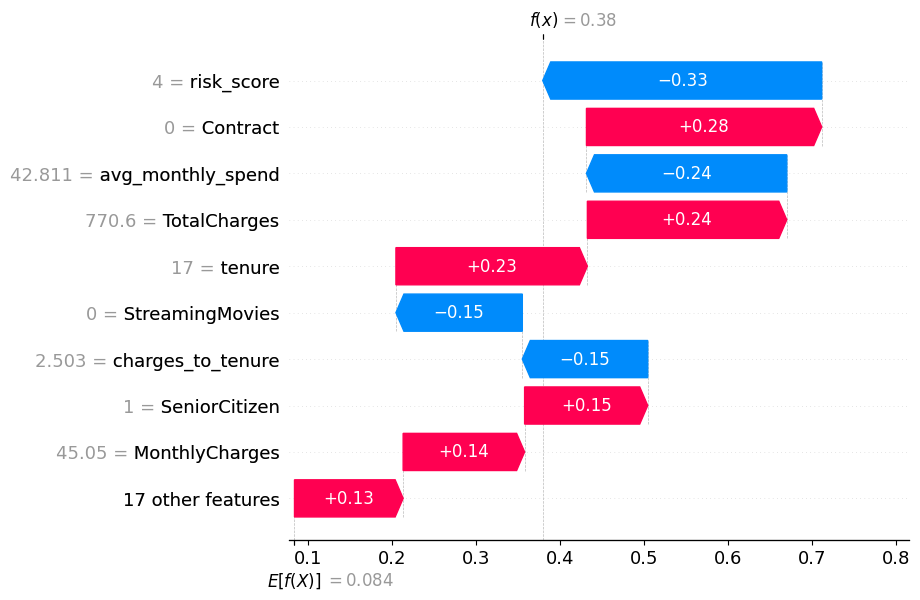

<Figure size 640x480 with 0 Axes>

✅ Waterfall plot saved!


In [ ]:
# ── Cell 14: Individual Prediction Explanation ────────────────────────────────
# Pick a churner from test set
churner_idx = y_test[y_test == 1].index[0]
churner_pos = X_test.index.get_loc(churner_idx)

print(f"🔍 Explaining prediction for customer at index: {churner_idx}")
print(f"   Actual: Churn={y_test[churner_idx]} | Predicted prob: {y_prob[churner_pos]:.2%}\n")

# Waterfall plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[churner_pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[churner_pos],
        feature_names=X_test.columns.tolist()
    )
)
plt.tight_layout()
plt.savefig("/content/shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Waterfall plot saved!")

In [ ]:
# ── Cell 15: Export for Tableau ───────────────────────────────────────────────
# Add predictions back to original dataframe
df_export = pd.read_csv("/content/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Add our engineered features & predictions
df_export["TotalCharges"] = pd.to_numeric(df_export["TotalCharges"], errors="coerce")
df_export["TotalCharges"] = df_export["TotalCharges"].fillna(df_export["MonthlyCharges"])

# Tenure group
df_export["tenure_group"] = pd.cut(
    df_export["tenure"],
    bins=[0, 12, 24, 48, 60, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-5yr", "5-6yr"],
    include_lowest=True
)

# Engineered features
df_export["service_count"] = df_export[["OnlineSecurity","OnlineBackup",
    "DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]]\
    .apply(lambda x: (x == "Yes").sum(), axis=1)

df_export["auto_payment"] = df_export["PaymentMethod"].isin(
    ["Bank transfer (automatic)", "Credit card (automatic)"]
).astype(int)

df_export["charges_to_tenure"] = df_export["MonthlyCharges"] / (df_export["tenure"] + 1)

df_export["risk_score"] = (
    (df_export["Contract"] == "Month-to-month").astype(int) * 3 +
    (df_export["tenure"] < 12).astype(int) * 2 +
    (df_export["InternetService"] == "Fiber optic").astype(int) * 2 +
    (df_export["auto_payment"] == 0).astype(int) * 1
)

# Add churn probability from our model
df_export["churn_probability"] = model.predict_proba(X)[:, 1]
df_export["churn_predicted"] = model.predict(X)

# Risk segment based on probability
df_export["churn_risk_segment"] = pd.cut(
    df_export["churn_probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Save
df_export.to_csv("/content/telco_churn_tableau.csv", index=False)
print(f"Export ready! Shape: {df_export.shape}")
print(f"\nRisk segment distribution:")
print(df_export["churn_risk_segment"].value_counts())
print(f"\n File saved: telco_churn_tableau.csv")

✅ Export ready! Shape: (7043, 29)

Risk segment distribution:
churn_risk_segment
Low Risk       3550
High Risk      2192
Medium Risk    1301
Name: count, dtype: int64

 File saved: telco_churn_tableau.csv


In [ ]:
# ── Cell 16: Download the file ────────────────────────────────────────────────
from google.colab import files
files.download("/content/telco_churn_tableau.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>